# 配套实践 05-03：训练一个小型图文对齐模型

本练习为颜色、形状和左右位置生成一一配对的图像与中文描述，训练一个简化的 CLIP 式双编码器。我们将观察双向损失、图文相似度矩阵和文本检索图像的结果，同时说明全局匹配为什么还不等于视觉定位。依赖：PyTorch、NumPy、Matplotlib；Google Colab 的 CPU 即可运行。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/05-language-encoding/" target="_blank">在新标签页返回课程正文</a>

In [1]:
import itertools  # 生成颜色、形状和位置的语义组合
import numpy as np  # 保存训练曲线并设置绘图坐标
import matplotlib.pyplot as plt  # 绘制配对样本、损失和相似度矩阵
import torch  # 构造图文张量并训练双编码器
from torch import nn  # 使用 embedding、线性层和模块基类
import torch.nn.functional as functional  # 使用归一化与交叉熵损失
torch.manual_seed(53)  # 固定模型初始化和训练过程的随机性
np.random.seed(53)  # 固定 NumPy 侧的随机性
torch.set_num_threads(2)  # 限制 CPU 线程数量以适合在线环境

## 1. 建立一批语义唯一的图文配对

四种颜色、两种形状和两个左右位置组成 16 个不同语义。每个训练 step 都会为这些语义重新生成背景、噪声和轻微位置扰动，但文本保持不变。这样 batch 中每条描述都有唯一配对，便于先理解相似度矩阵；真实数据中的同义文本和多视角正样本会更复杂。

In [2]:
image_size = 16  # 设置人工 RGB 图像的边长
color_specs = [("red", "红色", (0.95, 0.12, 0.12)), ("blue", "蓝色", (0.10, 0.28, 0.92)), ("green", "绿色", (0.10, 0.72, 0.30)), ("yellow", "黄色", (0.95, 0.72, 0.08))]  # 定义颜色名称和像素值
shape_specs = [("circle", "圆形"), ("square", "方块")]  # 定义两种目标形状
side_specs = [("left", "左侧"), ("right", "右侧")]  # 定义两个水平区域
semantic_rows = list(itertools.product(color_specs, shape_specs, side_specs))  # 生成全部十六种语义组合
commands = [f"{color[1]} {shape[1]} 在 {side[1]}" for color, shape, side in semantic_rows]  # 为每个语义生成中文描述
vocab_words = sorted({word for command in commands for word in command.split()})  # 收集教学文本中的全部 token
vocab = {word: index + 1 for index, word in enumerate(vocab_words)}  # 为真实 token 分配非零编号
vocab["[PAD]"] = 0  # 为补齐位置保留零编号
token_ids = torch.tensor([[vocab[word] for word in command.split()] for command in commands], dtype=torch.long)  # 把十六条文本变成规则 id 张量
token_mask = (token_ids != 0).float()  # 标记所有真实 token 位置
short_labels = [f"{color[0][0].upper()}{shape[0][0].upper()}{side[0][0].upper()}" for color, shape, side in semantic_rows]  # 创建热力图使用的短标签
assert token_ids.shape == (16, 4)  # 检查十六条文本及其序列长度
print("语义组合数量：", len(commands))  # 输出当前 batch 中的配对数量
print("示例描述：", commands[0], "；", commands[-1])  # 展示语义跨度的两个例子

语义组合数量： 16
示例描述： 红色 圆形 在 左侧 ； 黄色 方块 在 右侧


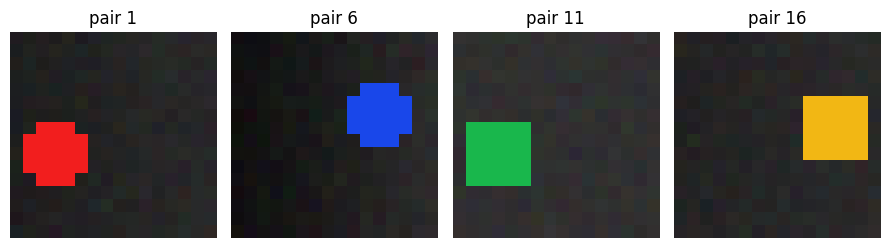

pair 1: 红色 圆形 在 左侧
pair 6: 蓝色 圆形 在 右侧
pair 11: 绿色 方块 在 左侧
pair 16: 黄色 方块 在 右侧


In [3]:
grid_y, grid_x = torch.meshgrid(torch.arange(image_size), torch.arange(image_size), indexing="ij")  # 建立绘制形状的像素网格
def render_batch(seed):  # 为十六种语义生成一批新的视觉外观
    generator = torch.Generator().manual_seed(seed)  # 为当前 batch 创建可重复随机源
    images = torch.empty((len(semantic_rows), 3, image_size, image_size), dtype=torch.float32)  # 预留全部 RGB 图像
    for index, (color, shape, side) in enumerate(semantic_rows):  # 按固定语义顺序逐张渲染
        background_level = 0.04 + float(torch.rand(1, generator=generator).item() * 0.18)  # 随机选择背景基础亮度
        horizontal_gradient = torch.linspace(0.0, float(torch.rand(1, generator=generator).item() * 0.12), image_size)  # 生成随机水平光照变化
        image = torch.ones((3, image_size, image_size), dtype=torch.float32) * background_level  # 初始化三通道背景
        image = image + horizontal_gradient.view(1, 1, image_size)  # 把光照渐变加入所有颜色通道
        image = image + torch.randn((3, image_size, image_size), generator=generator) * 0.012  # 添加轻微传感器噪声
        base_x = 4 if side[0] == "left" else 11  # 根据文本中的左右关系设置水平中心
        jitter_x = int(torch.randint(-1, 2, (1,), generator=generator).item())  # 添加不改变左右类别的水平扰动
        center_x = base_x + jitter_x  # 得到当前目标实际水平中心
        center_y = int(torch.randint(5, 12, (1,), generator=generator).item())  # 随机改变垂直位置避免固定模板
        circle_mask = (grid_x - center_x).square() + (grid_y - center_y).square() <= 6  # 计算圆形目标区域
        square_mask = (grid_x - center_x).abs() <= 2  # 计算方块的水平范围
        square_mask = square_mask & ((grid_y - center_y).abs() <= 2)  # 合并方块的垂直范围
        object_mask = circle_mask if shape[0] == "circle" else square_mask  # 根据文本语义选择目标形状
        color_tensor = torch.tensor(color[2], dtype=torch.float32).view(3, 1)  # 把目标颜色整理为三行向量
        image[:, object_mask] = color_tensor  # 在目标区域写入对应 RGB 颜色
        images[index] = image.clamp(0.0, 1.0)  # 保存有效范围内的人工图像
    return images  # 返回语义顺序固定而外观随机的图像 batch
preview_images = render_batch(seed=70)  # 生成一批只用于预览的配对图像
preview_indices = [0, 5, 10, 15]  # 选择覆盖多种颜色和形状的四个样本
fig, axes = plt.subplots(1, 4, figsize=(9, 2.5))  # 创建四个配对样本的横向画布
for sample_index, axis in zip(preview_indices, axes):  # 逐个显示图像并标注对应文本
    axis.imshow(preview_images[sample_index].permute(1, 2, 0))  # 把 CHW 图像转换为绘图通道顺序
    axis.set_title(f"pair {sample_index + 1}")  # 使用不依赖中文字体的样本编号
    axis.axis("off")  # 隐藏不必要的像素坐标
plt.tight_layout()  # 调整四幅图之间的间距
plt.show()  # 显示人工图文配对
for sample_index in preview_indices:  # 在图像下方列出编号对应的中文描述
    print(f"pair {sample_index + 1}: {commands[sample_index]}")  # 输出当前图像的配对文本

**怎样理解结果：** 文本描述只规定颜色、形状和左右区域，没有规定背景、精确坐标或垂直位置。模型若想在不断变化的图像中找到稳定配对，就必须优先利用与文本一致的因素。人工数据仍然远比真实机器人画面简单，本实验只用于理解图文对齐的计算接口。

## 2. 定义视觉编码器、语言编码器和相似度矩阵

视觉编码器读取 RGB 像素，语言编码器对 token embedding 做 masked pooling。两个编码器都输出 24 维向量，再归一化到单位长度。可学习的温度尺度控制相似度差异在交叉熵中的放大程度。

In [4]:
embedding_size = 24  # 设置图像和文本共同空间的维度
class ImageEncoder(nn.Module):  # 定义人工 RGB 图像的视觉编码器
    def __init__(self):  # 创建展平像素到共同表示的映射
        super().__init__()  # 初始化 PyTorch 模块基类
        self.network = nn.Sequential(nn.Flatten(), nn.Linear(3 * image_size * image_size, 96), nn.ReLU(), nn.Linear(96, embedding_size))  # 压缩像素并输出图文共同表示
    def forward(self, images):  # 定义视觉编码器前向计算
        return self.network(images)  # 返回尚未归一化的视觉向量
class TextEncoder(nn.Module):  # 定义教学文本的语言编码器
    def __init__(self, vocab_size):  # 接收包含 PAD 的词表大小
        super().__init__()  # 初始化 PyTorch 模块基类
        self.embedding = nn.Embedding(vocab_size, embedding_size, padding_idx=0)  # 创建忽略 PAD 的 token embedding
        self.projection = nn.Linear(embedding_size, embedding_size)  # 创建语言到共同空间的投影层
    def forward(self, ids, mask):  # 定义 token 到句子表示的前向计算
        token_features = self.embedding(ids)  # 查表得到每个 token 的连续向量
        weights = mask.unsqueeze(-1)  # 扩展 mask 以匹配 embedding 形状
        pooled = (token_features * weights).sum(dim=1) / weights.sum(dim=1).clamp_min(1.0)  # 只汇总真实 token 表示
        return self.projection(pooled)  # 把句子向量投影到图文共同空间
image_encoder = ImageEncoder()  # 创建待训练的视觉编码器
text_encoder = TextEncoder(len(vocab))  # 创建待训练的语言编码器
logit_scale = nn.Parameter(torch.tensor(np.log(10.0), dtype=torch.float32))  # 用对数形式保存可学习相似度尺度
def similarity_logits(images, ids, mask):  # 计算一个 batch 的完整图文相似度矩阵
    image_features = functional.normalize(image_encoder(images), dim=1)  # 归一化视觉表示以使用余弦相似度
    text_features = functional.normalize(text_encoder(ids, mask), dim=1)  # 归一化语言表示以使用余弦相似度
    scale = logit_scale.exp().clamp(max=100.0)  # 把对数参数恢复为稳定的正尺度
    return scale * image_features @ text_features.T, image_features, text_features  # 返回相似度矩阵和两种表示

## 3. 使用双向交叉熵训练

相似度矩阵的第 i 行表示第 i 幅图像对全部文本的分数，第 i 列表示第 i 条文本对全部图像的分数。由于本实验的十六种语义互不重复，对角线就是唯一正确配对。

In [5]:
trainable_parameters = list(image_encoder.parameters()) + list(text_encoder.parameters()) + [logit_scale]  # 汇总两个编码器和温度尺度参数
optimizer = torch.optim.Adam(trainable_parameters, lr=2e-3)  # 创建双编码器联合优化器
labels = torch.arange(len(semantic_rows))  # 规定相似度矩阵对角线为正确配对
loss_history = []  # 保存每一步的双向图文对齐损失
step_count = 260  # 设置轻量训练的更新步数
for step in range(step_count):  # 持续生成新外观并更新图文编码器
    train_images = render_batch(seed=1000 + step)  # 为相同语义生成新的背景和位置扰动
    logits, _, _ = similarity_logits(train_images, token_ids, token_mask)  # 计算当前十六乘十六相似度矩阵
    image_to_text_loss = functional.cross_entropy(logits, labels)  # 让每幅图像选择自己的配对文本
    text_to_image_loss = functional.cross_entropy(logits.T, labels)  # 让每条文本选择自己的配对图像
    loss = 0.5 * (image_to_text_loss + text_to_image_loss)  # 对两个检索方向取平均
    optimizer.zero_grad()  # 清除上一步累积的全部参数梯度
    loss.backward()  # 从双向损失计算两个编码器和尺度参数梯度
    optimizer.step()  # 根据当前梯度更新整个图文对齐模型
    loss_history.append(loss.item())  # 保存当前训练损失用于绘图
    if step in {0, 49, 129, 259}:  # 只在关键步骤报告训练进展
        print(f"step={step + 1:03d} | loss={loss.item():.4f} | scale={logit_scale.exp().item():.2f}")  # 输出损失和当前相似度尺度

step=001 | loss=3.3544 | scale=9.98
step=050 | loss=0.7059 | scale=10.48
step=130 | loss=0.6228 | scale=11.16
step=260 | loss=0.5225 | scale=13.04


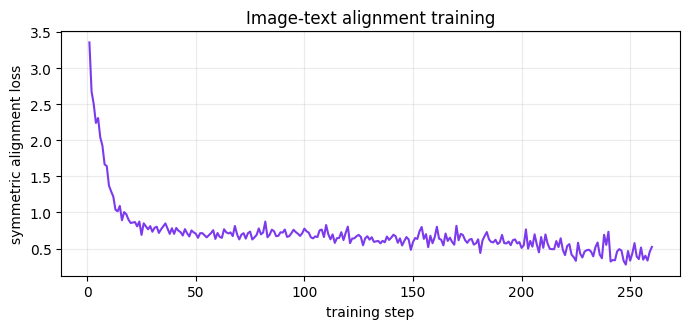

In [6]:
fig, axis = plt.subplots(figsize=(7, 3.4))  # 创建简洁的训练曲线画布
axis.plot(np.arange(1, step_count + 1), loss_history, color="#7c3aed")  # 绘制双向对齐损失随训练下降的过程
axis.set_xlabel("training step")  # 标注横轴为参数更新次数
axis.set_ylabel("symmetric alignment loss")  # 标注纵轴为双向对齐损失
axis.set_title("Image-text alignment training")  # 说明当前曲线内容
axis.grid(alpha=0.25)  # 添加较淡网格帮助读取趋势
plt.tight_layout()  # 调整图像边距
plt.show()  # 显示训练曲线

**怎样理解结果：** 损失下降说明模型越来越容易在当前 16 个候选中找到已知配对。尺度参数增大会放大相似度差异，但更尖锐的 Softmax 不代表模型一定获得了更可靠的真实世界语义。还必须使用未参与训练生成的图像检查相似度结构。

## 4. 在新背景上检查相似度矩阵

下面使用新的随机种子生成测试图像。热力图纵轴是图像，横轴是文本；亮色是否集中在对角线，比单独查看某一个最高分更能暴露颜色、形状或左右位置之间的混淆。短标签依次使用颜色、形状和位置的英文首字母，例如 `RCL` 表示 red-circle-left。

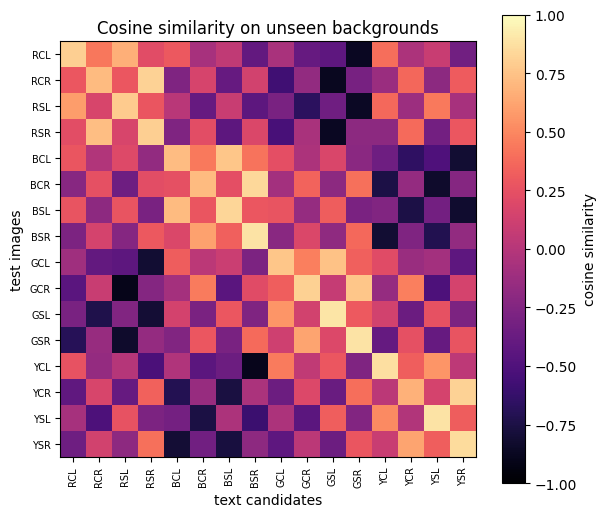

图像→文本准确率: 75.0%
文本→图像准确率: 87.5%


In [7]:
image_encoder.eval()  # 把视觉编码器切换到评估模式
text_encoder.eval()  # 把语言编码器切换到评估模式
test_images = render_batch(seed=9000)  # 生成训练中未出现的背景和位置扰动
with torch.no_grad():  # 评价阶段关闭梯度记录
    test_logits, test_image_features, test_text_features = similarity_logits(test_images, token_ids, token_mask)  # 计算测试图文相似度
    test_similarity = test_image_features @ test_text_features.T  # 使用未缩放余弦相似度便于解释
    image_to_text_accuracy = (test_similarity.argmax(dim=1) == labels).float().mean().item()  # 统计图像检索文本准确率
    text_to_image_accuracy = (test_similarity.argmax(dim=0) == labels).float().mean().item()  # 统计文本检索图像准确率
fig, axis = plt.subplots(figsize=(6.2, 5.4))  # 创建完整相似度矩阵画布
heatmap = axis.imshow(test_similarity.numpy(), cmap="magma", vmin=-1.0, vmax=1.0)  # 使用统一范围显示余弦相似度
axis.set_xticks(np.arange(len(short_labels)), short_labels, rotation=90, fontsize=7)  # 标注每一列对应的文本语义
axis.set_yticks(np.arange(len(short_labels)), short_labels, fontsize=7)  # 标注每一行对应的图像语义
axis.set_xlabel("text candidates")  # 说明横轴表示候选文本
axis.set_ylabel("test images")  # 说明纵轴表示测试图像
axis.set_title("Cosine similarity on unseen backgrounds")  # 说明热力图使用未见背景
fig.colorbar(heatmap, ax=axis, label="cosine similarity")  # 添加颜色数值说明
plt.tight_layout()  # 调整标签和色条边距
plt.show()  # 显示图文相似度矩阵
print(f"图像→文本准确率: {image_to_text_accuracy:.1%}")  # 报告按行选择文本的结果
print(f"文本→图像准确率: {text_to_image_accuracy:.1%}")  # 报告按列选择图像的结果

**怎样理解结果：** 对角线更亮表示配对图文在共同空间中更接近；对角线附近或其他位置的亮块则提示具体混淆。两个检索方向使用同一矩阵，却可能得到不同准确率。这里的高准确率只覆盖人工定义的 16 种封闭语义，不能外推到新词、复杂场景或真实相机。

## 5. 用一条文本比较容易混淆的候选图像

最后选择“绿色方块在右侧”，并只展示四个在颜色、形状或左右位置上相近的候选。这个过程是整图检索：每幅候选图中只有一个目标，因此它仍没有解决多物体画面中的区域 grounding。

In [ ]:
query_index = 11  # 选择绿色方块在右侧作为文本查询
candidate_indices = [11, 10, 9, 7]  # 选择正确图像和三个只差一种属性的候选
query_scores = test_similarity[candidate_indices, query_index]  # 读取查询文本对四幅候选图的相似度
fig, axes = plt.subplots(1, 4, figsize=(9, 2.6))  # 创建四个候选图像的横向画布
for candidate_index, score, axis in zip(candidate_indices, query_scores, axes):  # 逐个显示候选图和模型分数
    axis.imshow(test_images[candidate_index].permute(1, 2, 0))  # 显示当前候选 RGB 图像
    axis.set_title(f"{short_labels[candidate_index]}\nscore={score.item():.2f}")  # 标注候选语义和余弦相似度
    axis.axis("off")  # 隐藏不必要的像素坐标
plt.suptitle("query: green square on the right")  # 使用英文标题避免本地字体缺失
plt.tight_layout()  # 调整标题和候选图间距
plt.show()  # 显示难候选检索结果
best_candidate = candidate_indices[int(query_scores.argmax().item())]  # 找出四个候选中的最高分图像
print("查询文本：", commands[query_index])  # 输出实际使用的中文查询
print("最高分候选：", commands[best_candidate])  # 输出模型最终选择的候选语义

**怎样理解结果：** 正确候选应同时满足绿色、方块和右侧三个条件。只改变左右、形状或颜色的候选属于难负样本，它们能比完全无关图像更有效地检查表示是否保留关键属性。若模型选对整幅图，只能说明它完成了候选检索；当多个物体出现在同一画面时，还需要区域特征或分割结果指出目标究竟位于哪里。

## 结论与练习

双编码器把两种模态映射到共同空间，相似度矩阵同时训练图像找文本和文本找图像。尝试删除文本中的“左侧/右侧”，观察左右候选是否变得不可区分；也可以让 batch 中出现两幅语义相同的图像，检查一一配对标签为什么会把另一个真实正样本当成错误候选。